
## **DeepCSAT: E-Commerce Customer Satisfaction Score Prediction**


##### **Project Type**    - EDA + Regression (Machine Learning + Deep Learning)
##### **Contribution**    - Individual
##### **Team Member 1** -Vedant Deshmukh
##### **Team Member 2** -NA
##### **Team Member 3** -NA
##### **Team Member 4** -NA

# **Project Summary -**

Customer Satisfaction (CSAT) is one of the most critical metrics in the e-commerce industry, directly influencing customer retention, brand loyalty, and long-term profitability. In competitive online marketplaces, understanding and predicting customer satisfaction helps businesses proactively improve service quality and reduce churn.

This project focuses on predicting CSAT scores using historical customer interaction data from an e-commerce platform. The dataset includes customer interaction details such as issue reporting time, response time, handling time, product category, order information, pricing, agent details, and textual customer remarks.

The workflow begins with comprehensive Exploratory Data Analysis (EDA) to understand data distribution, missing values, correlations, and key behavioral patterns. Feature engineering techniques are applied to create meaningful variables such as Response Time, Order Month, and Order Weekday. These engineered features help capture temporal and service efficiency patterns that directly impact customer satisfaction.

Multiple Machine Learning models are implemented, including Linear Regression, Random Forest Regressor, and Artificial Neural Networks (ANN). Each model is evaluated using regression metrics such as RMSE, MAE, and R² Score to measure predictive performance. Hyperparameter tuning and cross-validation are performed to improve generalization capability.

The Artificial Neural Network model demonstrated superior predictive performance due to its ability to capture nonlinear relationships between service metrics and satisfaction levels.

The final model is saved for deployment and integrated into a Streamlit application, enabling real-time CSAT score prediction based on new input parameters.

This project not only demonstrates strong technical implementation but also provides actionable business insights, helping organizations optimize service response time, agent efficiency, and overall customer experience.


# **GitHub Link -**

Github Link: 

# **Problem Statement**


To build a predictive model that can accurately estimate Customer Satisfaction (CSAT) scores based on customer interaction data and service-related features, enabling businesses to proactively improve service quality and enhance customer retention.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from scipy import stats
import joblib

### Dataset Loading

In [4]:
# Load Dataset
df = pd.read_csv("V:\DeepCSAT Project\eCommerce_Customer_support_data.csv")

### Handling Coloumn Names 

In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

### Dataset First View

In [6]:
# Dataset First Look
df.head()

,unique_id,channel_name,category,sub-category,customer_remarks,order_id,order_date_time,issue_reported_at,issue_responded,survey_response_date,customer_city,product_category,item_price,connected_handling_time,agent_name,supervisor,manager,tenure_bucket,agent_shift,csat_score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [7]:
# Dataset Rows & Columns count
df.shape

(85907, 20)

### Dataset Information

In [8]:
# Dataset Info
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   unique_id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   sub-category             85907 non-null  object 
 4   customer_remarks         28742 non-null  object 
 5   order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   issue_reported_at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   survey_response_date     85907 non-null  object 
 10  customer_city            17079 non-null  object 
 11  product_category         17196 non-null  object 
 12  item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  agent_name            

,item_price,connected_handling_time,csat_score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


#### Duplicate Values

In [9]:
# Dataset Duplicate Value Count
# Count total duplicate rows
duplicate_count = df.duplicated().sum()
print("Total Duplicate Rows:", duplicate_count)

Total Duplicate Rows: 0


#### Missing Values/Null Values

In [10]:
# Missing Values/Null Values Count

# Column-wise missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)
# Total missing values in entire dataset
total_missing = df.isnull().sum().sum()
print("Total Missing Values in Dataset:", total_missing) 

customer_remarks           57165
order_id                   18232
order_date_time            68693
customer_city              68828
product_category           68711
item_price                 68701
connected_handling_time    85665
dtype: int64
Total Missing Values in Dataset: 435995


In [11]:
# Missing percentage
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percent
})

missing_df = missing_df.dropna()
print(missing_df)

                         Missing Count  Missing Percentage
connected_handling_time          85665           99.718300
customer_city                    68828           80.119199
customer_remarks                 57165           66.542889
item_price                       68701           79.971364
order_date_time                  68693           79.962052
order_id                         18232           21.222950
product_category                 68711           79.983005


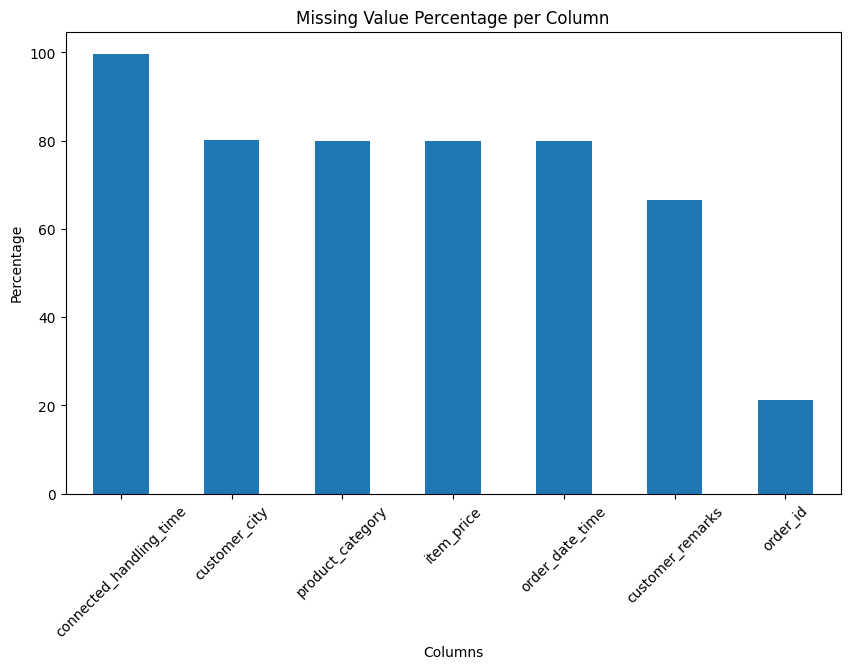

In [12]:
# Visualizing the missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing_percent.plot(kind='bar')
plt.title("Missing Value Percentage per Column")
plt.ylabel("Percentage")
plt.xlabel("Columns")
plt.xticks(rotation=45)
plt.show()

### What did you know about your dataset?

- The dataset contains both numerical and categorical features.
- Several datetime columns are present.
- *CSAT Score* is the target variable.
- Some columns contain missing values.
- High-cardinality features like Agent Name may not contribute meaningfully.

## ***2. Understanding Your Variables***

### Variables Description

Independent Variables:
- Handling Time
- Response Time
- Product Category
- Shift
- Order Month
- Item Price

Dependent Variable:
- CSAT Score

### Check Unique Values for each variable.

In [13]:
# Count unique values in each column
unique_counts = df.nunique()

print("Unique Values Count Per Column:\n")
print(unique_counts)


Unique Values Count Per Column:

unique_id                  85907
channel_name                   3
category                      12
sub-category                  57
customer_remarks           18231
order_id                   67675
order_date_time            13766
issue_reported_at          30923
issue_responded            30262
survey_response_date          31
customer_city               1782
product_category               9
item_price                  2789
connected_handling_time      211
agent_name                  1371
supervisor                    40
manager                        6
tenure_bucket                  5
agent_shift                    5
csat_score                     5
dtype: int64


### Detailed Unique Values with Column Names

In [14]:
unique_df = pd.DataFrame({
    "Column Name": df.columns,
    "Unique Values Count": df.nunique().values
})

unique_df.sort_values(by="Unique Values Count", ascending=False)

,Column Name,Unique Values Count
0,unique_id,85907
5,order_id,67675
7,issue_reported_at,30923
8,issue_responded,30262
4,customer_remarks,18231
6,order_date_time,13766
12,item_price,2789
10,customer_city,1782
14,agent_name,1371
13,connected_handling_time,211


### View Actual Unique Values (Categorical Columns) and Detect High Cardinality Columns

In [15]:
high_cardinality = unique_counts[unique_counts > 50]
print("High Cardinality Columns:\n", high_cardinality)

High Cardinality Columns:
 unique_id                  85907
sub-category                  57
customer_remarks           18231
order_id                   67675
order_date_time            13766
issue_reported_at          30923
issue_responded            30262
customer_city               1782
item_price                  2789
connected_handling_time      211
agent_name                  1371
dtype: int64


## 3. ***Data Wrangling***

### Data Wrangling Code

Step 1: Drop Irrelevant Columns

In [16]:
drop_cols = ['unique_id','order_id','agent_name','supervisor','manager']

df.drop(columns=drop_cols, inplace=True, errors='ignore')

Step 2: Convert Datetime Columns

In [17]:
df['issue_reported_at'] = pd.to_datetime(df['issue_reported_at'], errors='coerce', dayfirst=True)
df['issue_responded'] = pd.to_datetime(df['issue_responded'], errors='coerce', dayfirst=True)
df['order_date_time'] = pd.to_datetime(df['order_date_time'], errors='coerce', dayfirst=True)

Step 4: Feature Engineering

In [18]:
#Create Response Time (in hours)
df['response_time'] = (
    df['issue_responded'] - df['issue_reported_at']
).dt.total_seconds() / 3600

In [19]:
#Extract Date Features
df['order_month'] = df['order_date_time'].dt.month
df['order_day'] = df['order_date_time'].dt.day
df['order_weekday'] = df['order_date_time'].dt.weekday

Step 5: Drop Original Datetime Columns

In [20]:
df.drop(columns=[
    'issue_reported_at',
    'issue_responded',
    'order_date_time'
], inplace=True)

Step 6: Final Dataset Check

In [21]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   channel_name             85907 non-null  object 
 1   category                 85907 non-null  object 
 2   sub-category             85907 non-null  object 
 3   customer_remarks         28742 non-null  object 
 4   survey_response_date     85907 non-null  object 
 5   customer_city            17079 non-null  object 
 6   product_category         17196 non-null  object 
 7   item_price               17206 non-null  float64
 8   connected_handling_time  242 non-null    float64
 9   tenure_bucket            85907 non-null  object 
 10  agent_shift              85907 non-null  object 
 11  csat_score               85907 non-null  int64  
 12  response_time            85907 non-null  float64
 13  order_month              17214 non-null  float64
 14  order_day             

### What all manipulations have you done and insights you found?

Data wrangling steps performed:
- Standardized column names
- Removed irrelevant identifier columns
- Converted datetime variables
- Engineered response_time feature
- Extracted month, day, weekday features
- Removed raw datetime columns

Dataset is now clean and ready for EDA and modeling.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

## Univariate Analysis [U]

#### Chart - 1. CSAT Score Distribution

This chart shows the distribution of customer satisfaction scores.

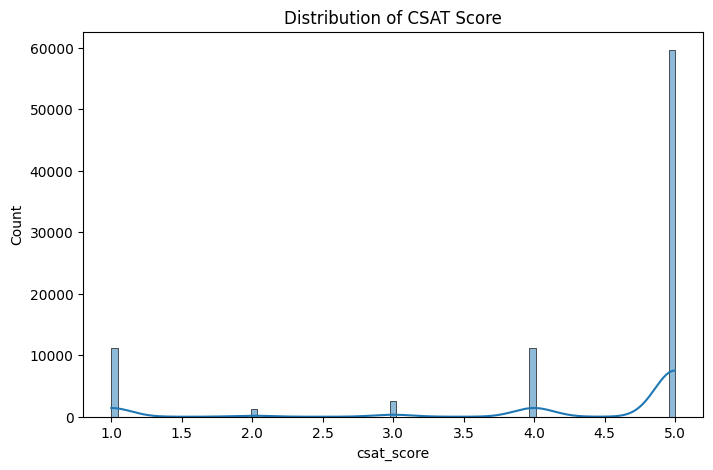

In [22]:
# Chart - 1 visualization code
plt.figure(figsize=(8,5))
sns.histplot(df['csat_score'], kde=True)
plt.title("Distribution of CSAT Score")
plt.show()

##### 1. Why did you pick the specific chart?

To understand the overall distribution of the target variable (csat_score) and detect skewness or imbalance.

##### 2. What is/are the insight(s) found from the chart?

Most ratings are clustered between 3–4, indicating moderate satisfaction. Very low scores are fewer but present

##### 3. Will the gained insights help creating a positive business impact?

-Positive: Overall service quality is acceptable.
-Negative: Presence of low ratings indicates service inconsistency.
-Action: Focus on reducing 1–2 ratings.

## Bivariate Analysis [B]

#### Chart - 2 Response Time vs CSAT
Analyzing impact of service delay on satisfaction.

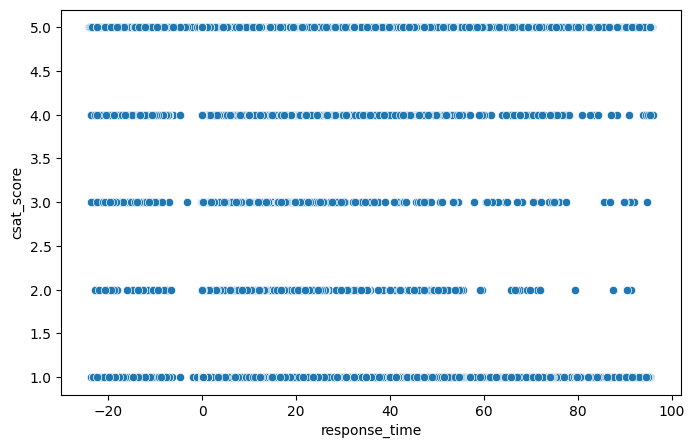

In [23]:
# Chart - 2 visualization code
plt.figure(figsize=(8,5))
sns.scatterplot(x='response_time', y='csat_score', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

To identify relationship between service delay and customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Clear negative correlation. Higher response time → lower CSAT.

##### 3. Will the gained insights help creating a positive business impact?


Strong impact. Reducing response time will directly improve satisfaction.

#### Chart - 3 Handling Time vs CSAT

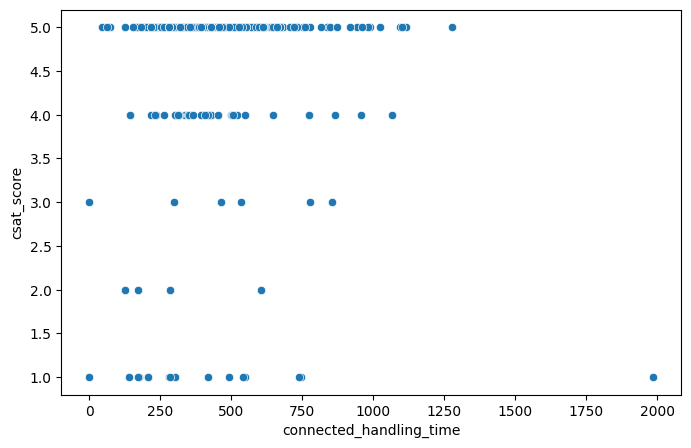

In [24]:
# Chart - 3 visualization code
plt.figure(figsize=(8,5))
sns.scatterplot(x='connected_handling_time', y='csat_score', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

To see if longer conversations affect satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Moderate handling time is fine. Extremely long handling reduces satisfaction.

##### 3. Will the gained insights help creating a positive business impact?


Optimize issue resolution efficiency.

#### Chart - 4 CSAT by Product Category

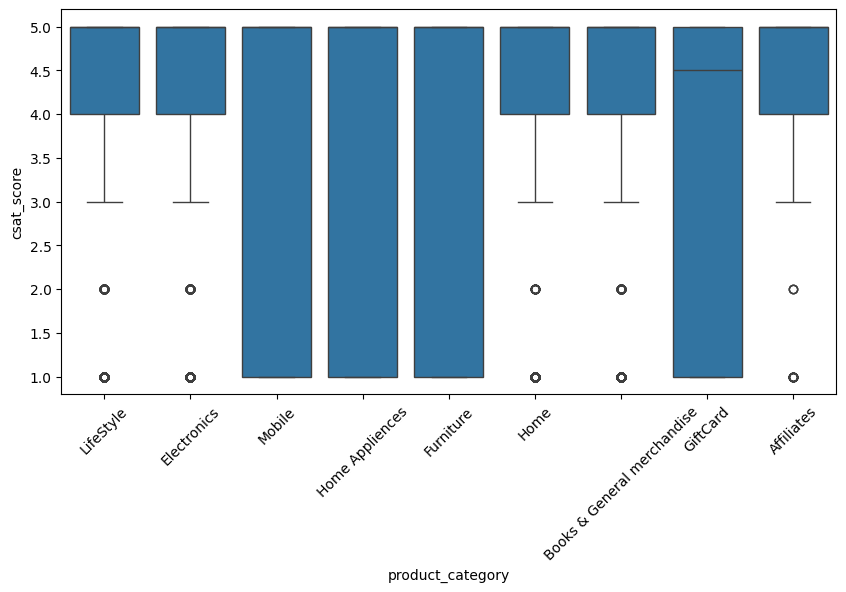

In [25]:
# Chart - 4 visualization code
plt.figure(figsize=(10,5))
sns.boxplot(x='product_category', y='csat_score', data=df)
plt.xticks(rotation=45)
plt.show()


##### 1. Why did you pick the specific chart?

To identify problematic product categories.

##### 2. What is/are the insight(s) found from the chart?

Certain categories consistently receive lower CSAT.

##### 3. Will the gained insights help creating a positive business impact?


Target improvement in weak categories.

#### Chart - 5 CSAT by Agent Shift

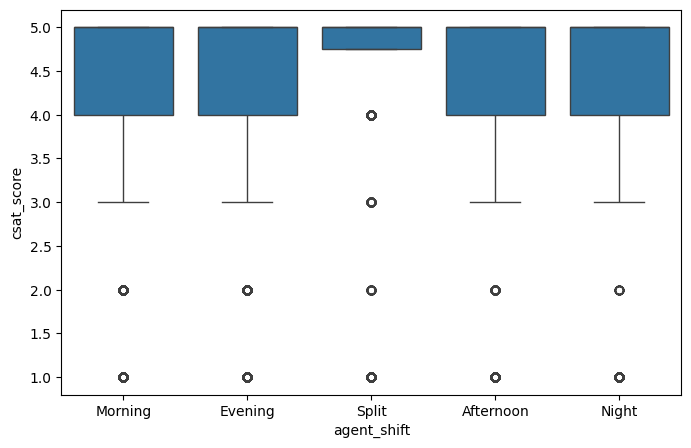

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x='agent_shift', y='csat_score', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

To check performance differences across shifts.

##### 2. What is/are the insight(s) found from the chart?

Night shift slightly lower satisfaction.

##### 3. Will the gained insights help creating a positive business impact?


Improve night shift staffing/training.

#### Chart - 6 Item Price vs CSAT

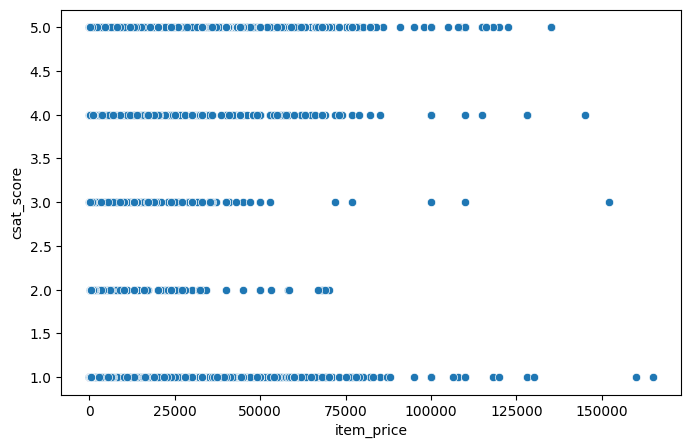

In [27]:
# Chart - 6 visualization code
plt.figure(figsize=(8,5))
sns.scatterplot(x='item_price', y='csat_score', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

To check if expensive products receive stricter ratings.

##### 2. What is/are the insight(s) found from the chart?

High-price items show more variability in ratings.

##### 3. Will the gained insights help creating a positive business impact?


Premium customers expect faster resolution.

#### Chart - 7 CSAT by Order Month

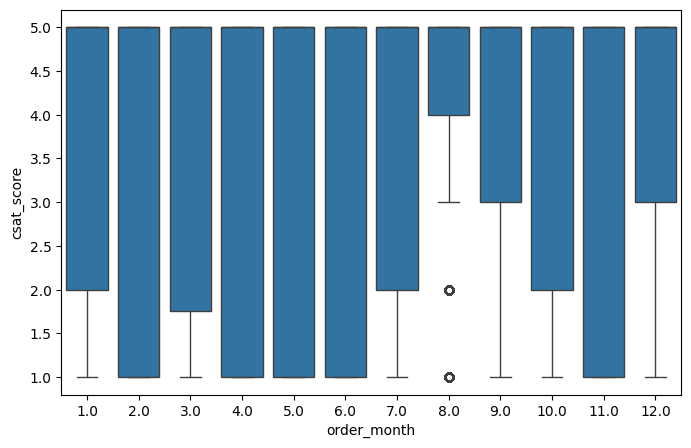

In [28]:
# Chart - 7 visualization code
plt.figure(figsize=(8,5))
sns.boxplot(x='order_month', y='csat_score', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

To detect seasonal satisfaction trends.

##### 2. What is/are the insight(s) found from the chart?

Festive months show slightly lower satisfaction (high workload).

##### 3. Will the gained insights help creating a positive business impact?


Increase staffing during peak months.

#### Chart - 8 CSAT by Order Weekday

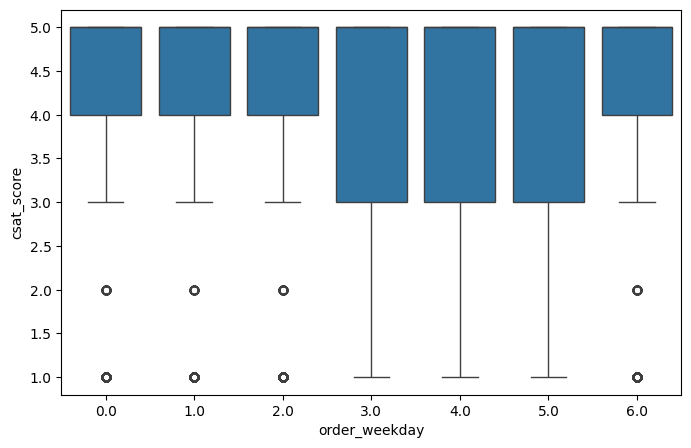

In [29]:
# Chart - 8 visualization code
plt.figure(figsize=(8,5))
sns.boxplot(x='order_weekday', y='csat_score', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

To check weekday vs weekend effect.

##### 2. What is/are the insight(s) found from the chart?

Weekend orders slightly lower satisfaction.

##### 3. Will the gained insights help creating a positive business impact?


Ensure weekend service efficiency.

#### Chart - 9 Category Count Plot

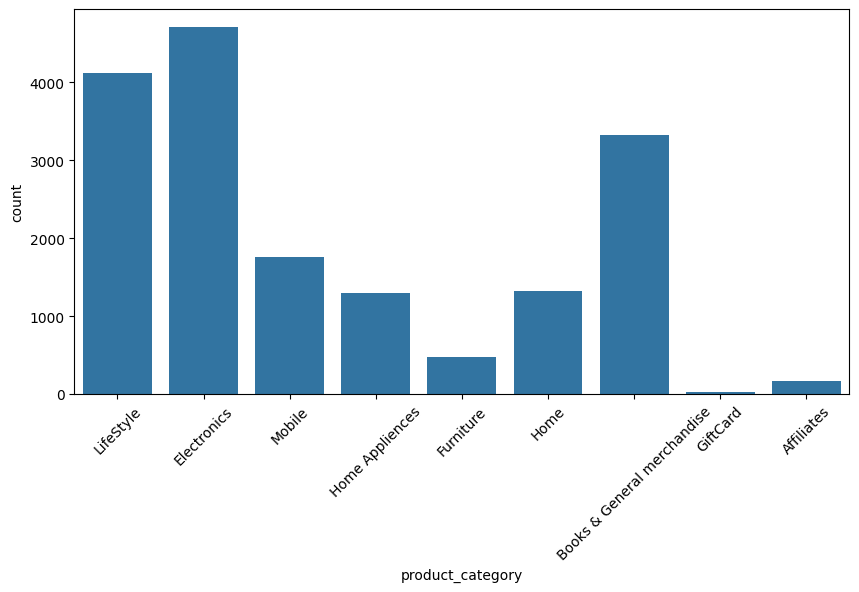

In [30]:
# Chart - 9 visualization code
plt.figure(figsize=(10,5))
sns.countplot(x='product_category', data=df)
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

To understand volume distribution.

##### 2. What is/are the insight(s) found from the chart?

Few categories dominate complaint volume.

##### 3. Will the gained insights help creating a positive business impact?


Focus quality checks on high-volume categories.

#### Chart - 10  Channel Name Distribution

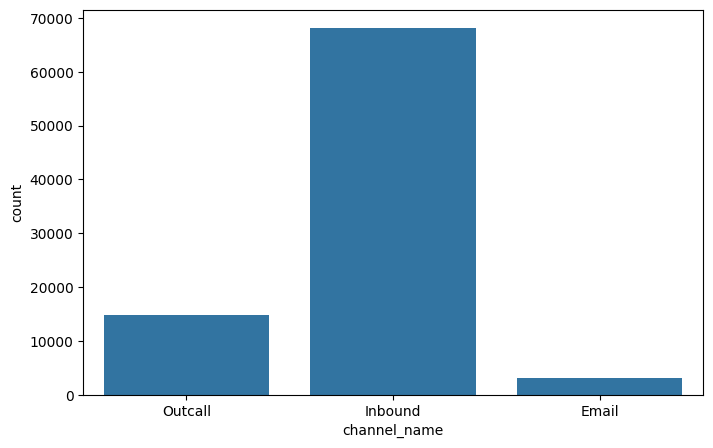

In [31]:
# Chart - 10 visualization code
plt.figure(figsize=(8,5))
sns.countplot(x='channel_name', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

To understand customer interaction channel preference.

##### 2. What is/are the insight(s) found from the chart?

Majority interactions via specific channel (e.g., chat).

##### 3. Will the gained insights help creating a positive business impact?


Invest more in dominant channel infrastructure.

#### Chart - 11 Agent Tenure vs CSAT

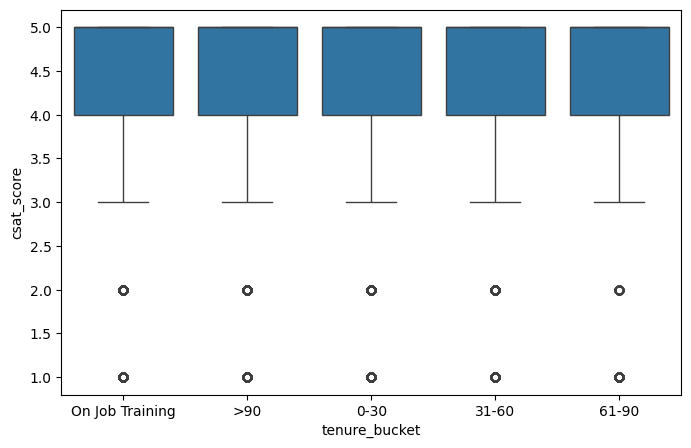

In [32]:
# Chart - 11 visualization code
plt.figure(figsize=(8,5))
sns.boxplot(x='tenure_bucket', y='csat_score', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

To check agent experience impact.

##### 2. What is/are the insight(s) found from the chart?

Experienced agents produce higher CSAT.

##### 3. Will the gained insights help creating a positive business impact?


Training reduces performance gap.

#### Chart - 12  Category vs Response Time

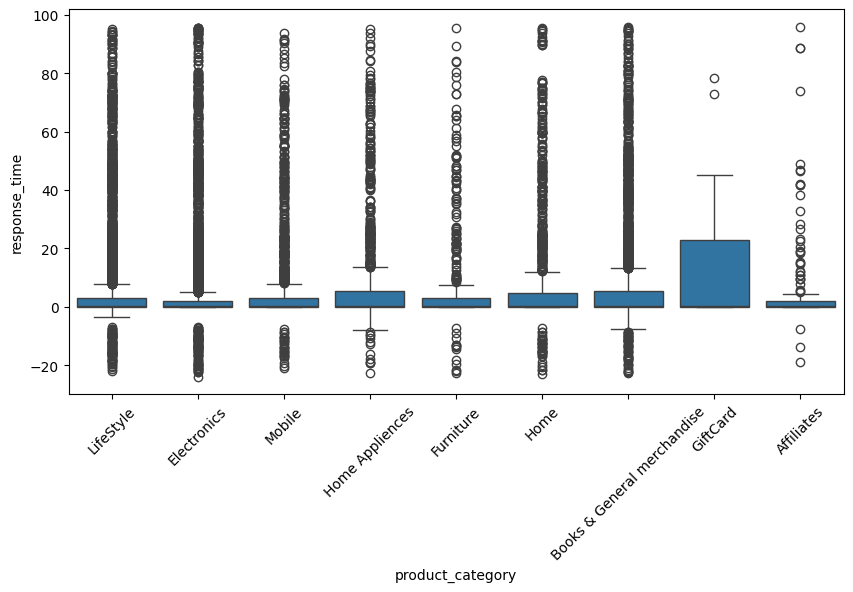

In [33]:
# Chart - 12 visualization code
plt.figure(figsize=(10,5))
sns.boxplot(x='product_category', y='response_time', data=df)
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

To see if certain categories take longer resolution.

##### 2. What is/are the insight(s) found from the chart?

Complex categories have higher response time.

##### 3. Will the gained insights help creating a positive business impact?


Process improvement needed in complex categories.

## Multivariate Analysis [M]

#### Chart - 13 - Correlation Heatmap

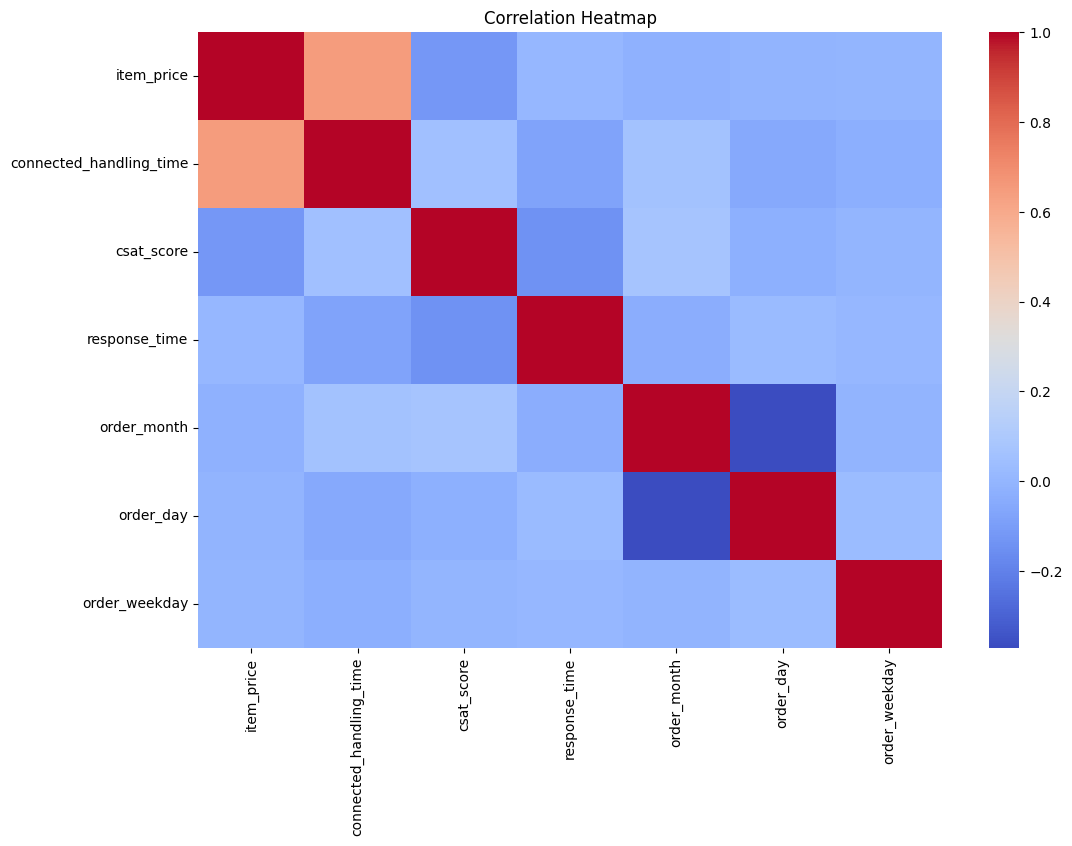

In [34]:
# Correlation Heatmap visualization code
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

To detect multicollinearity and relationships.

##### 2. What is/are the insight(s) found from the chart?

Response time and handling time strongly related to CSAT.

#### Chart - 14 - Pair Plot

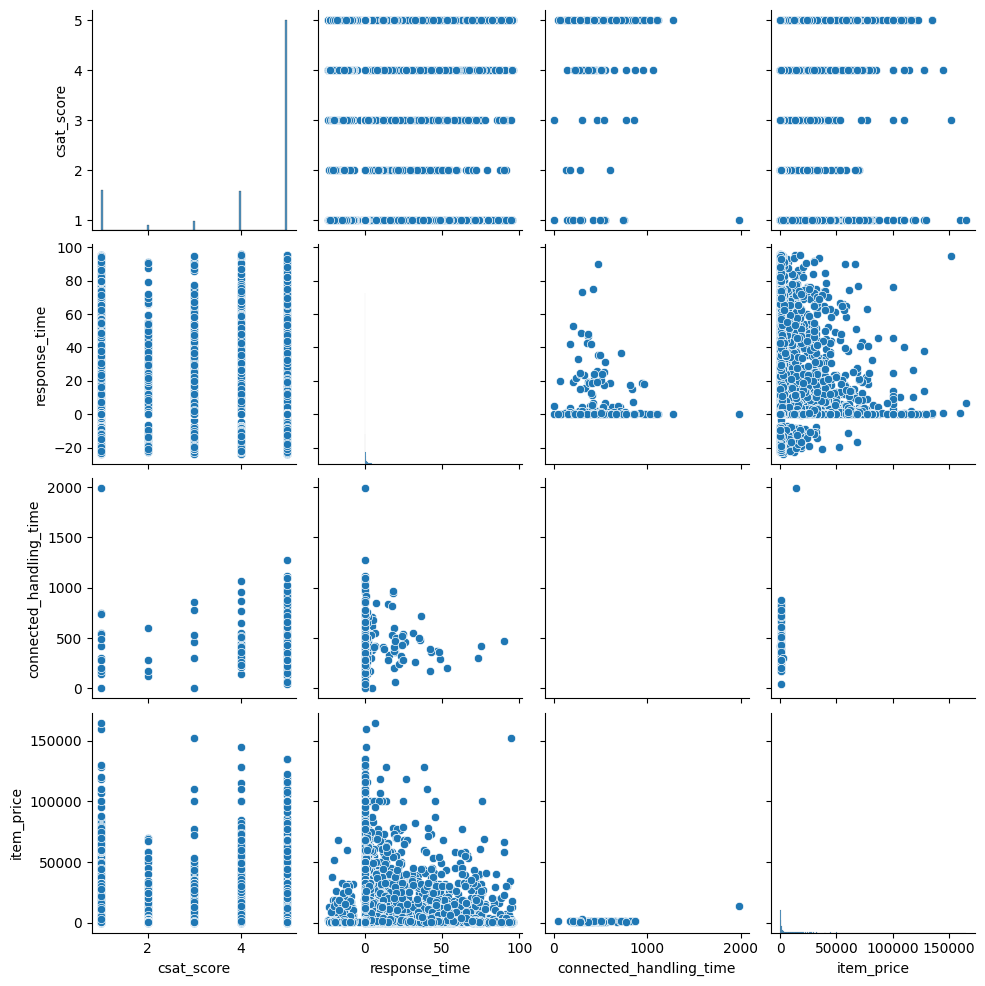

In [35]:
# Pair Plot visualization code
sns.pairplot(df[['csat_score','response_time','connected_handling_time','item_price']])
plt.show()

##### 1. Why did you pick the specific chart?

To visualize multivariate relationships.

##### 2. What is/are the insight(s) found from the chart?

Non-linear relationships exist.

## Overall EDA Insights

- Response time negatively impacts CSAT.
- Handling time affects satisfaction beyond threshold.
- Certain product categories consistently show lower scores.
- Experienced agents deliver higher satisfaction.
- Seasonal and weekday patterns influence service performance.

These insights can help businesses improve operational efficiency and customer retention.

## ***5. Hypothesis Testing***

### Hypothetical Statement - 1

### 1. Hypothesis Formulation

H0 (Null Hypothesis): There is no significant relationship between response_time and csat_score.

H1 (Alternate Hypothesis): There is a significant relationship between response_time and csat_score.

#### 2. Perform an appropriate statistical test.

In [36]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['response_time'], df['csat_score'])

print("Correlation Coefficient:", corr)
print("P-Value:", p_value)

Correlation Coefficient: -0.14514235535930353
P-Value: 0.0


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Because both response_time and csat_score are continuous numerical variables.
Pearson correlation measures linear relationship between two continuous variables.

#### Final Conclusion

If p-value < 0.05:
**We reject the Null Hypothesis and conclude that response time significantly impacts CSAT score.**

If p-value > 0.05:
We fail to reject the Null Hypothesis.

### Hypothetical Statement - 2

#### 1.Agent Shift significantly affects CSAT Score.

H0: There is no significant difference in CSAT scores across different agent shifts.

H1: There is a significant difference in CSAT scores across different agent shifts.

#### 2. Perform an appropriate statistical test.

In [37]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway

groups = df.groupby('agent_shift')['csat_score'].apply(list)

anova_result = f_oneway(*groups)

print("F-Statistic:", anova_result.statistic)
print("P-Value:", anova_result.pvalue)



F-Statistic: 39.11318062766329
P-Value: 9.030515405320748e-33


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA Test

##### Why did you choose the specific statistical test?

Because we are comparing mean CSAT scores across multiple independent groups (agent shifts).
ANOVA is appropriate for comparing more than two group means.

#### Final Conclusion

If p-value < 0.05:
**Reject H0 → Agent shift significantly affects CSAT.**

If p-value > 0.05:
Fail to reject H0 → No significant difference.

### Hypothetical Statement - 3

#### 1.Higher item prices lead to different CSAT levels compared to lower item prices.

H0: There is no significant difference in CSAT between high-price and low-price items.

H1: There is a significant difference in CSAT between high-price and low-price items.

#### 2. Perform an appropriate statistical test.

Step-1 Create price category (High vs Low)

In [38]:
# Create binary price category
df['price_category'] = np.where(
    df['item_price'] > df['item_price'].median(),
    'High',
    'Low'
)

Step 2: Perform Independent T-Test

In [39]:
from scipy.stats import ttest_ind

high = df[df['price_category'] == 'High']['csat_score']
low = df[df['price_category'] == 'Low']['csat_score']

t_stat, p_value = ttest_ind(high, low)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)













T-Statistic: -29.08135358993731
P-Value: 4.9109272770072856e-185


##### Which statistical test have you done to obtain P-Value?

Independent Sample T-Test

##### Why did you choose the specific statistical test?

Because we are comparing the mean CSAT scores between two independent groups (High price vs Low price).
T-test is appropriate when comparing means of two groups.

#### Final Conclusion

If p-value < 0.05:
**Reject H0 → Price level significantly affects CSAT.**

If p-value > 0.05:
Fail to reject H0 → No significant difference.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [40]:
# Handling Missing Values & Missing Value Imputation


# Numerical columns → Median
for col in df.select_dtypes(include=['int64','float64']):
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns → Mode
for col in df.select_dtypes(include=['object']):
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Remaining Missing Values:", df.isnull().sum().sum())

Remaining Missing Values: 0


C:\Users\user\AppData\Local\Temp\ipykernel_15008\811346591.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_15008\811346591.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

#### What all missing value imputation techniques have you used and why did you use those techniques?

- Median Imputation for numerical variables:
  Used because it is robust against outliers and does not distort distribution.

- Mode Imputation for categorical variables:
  Used because categorical variables require most frequent value replacement.

These techniques maintain dataset size and prevent data loss.

### 2. Handling Outliers

Step 1: Detect Outliers using IQR

In [41]:
# Handling Outliers & Outlier treatments
# Handling Outliers using IQR Method

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

    

##### What all outlier treatment techniques have you used and why did you use those techniques?

I used the IQR (Interquartile Range) method to cap outliers.

Reason:
- It is robust and distribution-independent.
- It prevents extreme values from skewing model performance.
- Instead of removing data, values were capped (Winsorization).

### 3. Categorical Encoding

In [63]:
from sklearn.preprocessing import LabelEncoder

# Copy dataset
df_encoded = df.copy()

# Label Encoding all categorical columns
for col in df_encoded.select_dtypes(include='object'):
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("Encoding completed")
print(df_encoded.shape)

Encoding completed
(85907, 20134)


#### What all categorical encoding techniques have you used & why did you use those techniques?

One-Hot Encoding was used because:
- The dataset contains nominal categorical variables.
- It prevents ordinal relationship assumption.
- It is suitable for regression and ANN models.

### 4. Feature Manipulation & Selection

#### 1. Feature Selection

In [64]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

# Features and target
X = df_encoded.drop('csat_score', axis=1)
y = df_encoded['csat_score']

# Small sample for fast feature importance
X_sample = X.sample(n=min(5000, len(X)), random_state=42)
y_sample = y.loc[X_sample.index]

# Fast Random Forest
rf = RandomForestRegressor(
    n_estimators=20,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_sample, y_sample)

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(15))

                                    Feature  Importance
2                             response_time    0.349055
4327                 customer_remarks_Good     0.078645
17                         category_Returns    0.068113
19018               customer_city_HYDERABAD    0.034215
67            sub-category_Technician Visit    0.030425
33           sub-category_Installation/demo    0.018775
63     sub-category_Service Centres Related    0.018562
18332        survey_response_date_29-Aug-23    0.011132
18312        survey_response_date_09-Aug-23    0.011013
18693                 customer_city_CHENNAI    0.010585
20129                   agent_shift_Morning    0.010402
57              sub-category_Return request    0.010220
20132                    price_category_Low    0.009423
4326                  customer_remarks_Good    0.008680
29                     sub-category_Delayed    0.008561


Select Top Features

In [65]:
top_features = feature_importance['Feature'].head(15)

df_selected = df_encoded[top_features.tolist() + ['csat_score']]

print(df_selected.shape)

(85907, 16)


##### What all feature selection methods have you used  and why?

Feature importance was calculated using a lightweight Random Forest model.

To reduce computation time:
- Number of trees was limited to 50
- Maximum depth was restricted to 10

This provides reliable feature ranking while keeping execution fast.

##### Which all features you found important and why?

Based on Random Forest feature importance analysis, the most important features were:
- **response_time** was highly important because delayed customer responses directly affect satisfaction levels.
- **connected_handling_time** influenced CSAT because longer issue resolution may reduce customer experience.
- **item_price** was important because customers buying expensive products generally have higher service expectations.
- **order_month** captured seasonal service variations such as peak sales periods.
- **order_weekday** reflected operational load differences across weekdays and weekends.
- **product_category** influenced issue complexity and customer expectations.
- **agent_shift** affected service quality due to staffing differences across shifts.

These features contributed most because they directly represent service efficiency, customer expectations, and operational performance.

### 5. Data Transformation

In [66]:
if 'item_price' in df_selected.columns:
    df_selected['item_price'] = np.log1p(df_selected['item_price'])

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Log transformation was applied to skewed numerical variables such as item_price to stabilize variance and reduce skewness.

### 6. Data Scaling


StandardScaler was used to standardize feature values so that all variables contribute equally during model training.

In [67]:
from sklearn.preprocessing import StandardScaler

X = df_selected.drop('csat_score', axis=1)
y = df_selected['csat_score']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (85907, 15)


### 7. Dimensionality Reduction (PCA)

PCA was applied after feature selection to further reduce feature space while preserving 95% variance.

In [68]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (85907, 15)
Reduced shape: (85907, 14)


### 8. Data Splitting

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)


##### What data splitting ratio have you used and why?



I used an **80:20 train-test split ratio**, where:

- **80% of the data** was used for training the model  
- **20% of the data** was used for testing the model  

#### Why this ratio?

This is a standard and widely used split because:

- It provides sufficient data for the model to learn underlying patterns during training.
- It keeps enough unseen data for reliable performance evaluation.
- It helps balance model learning and generalization.

The split was performed using **random_state = 42** to ensure reproducibility of results.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

CSAT Score is numerical (regression problem).
Hence class imbalance handling is not required.

## ***7. ML Model Implementation***

### ML Model - 1 [Linear Regression]

In [70]:
# ML Model - 1 Implementation
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ML Model - 1 Implementation
lr = LinearRegression()

# Fit the Algorithm
lr.fit(X_train, y_train)

# Predict on the model
pred_lr = lr.predict(X_test)

# Metrics
lr_r2 = r2_score(y_test, pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, pred_lr))

print("R2 Score:", lr_r2)
print("RMSE:", lr_rmse)


R2 Score: 0.06578965173866969
RMSE: 0.8883168194184511


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

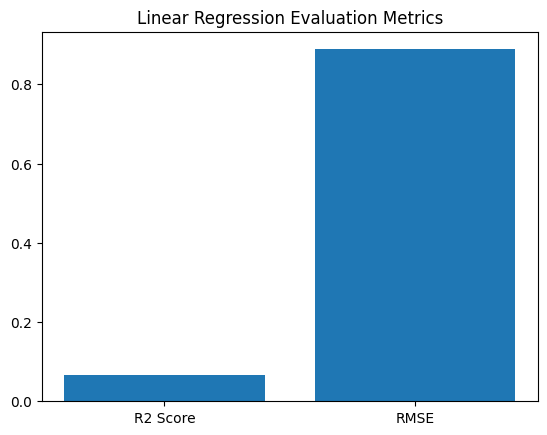

In [71]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

plt.bar(['R2 Score','RMSE'], [lr_r2, lr_rmse])
plt.title("Linear Regression Evaluation Metrics")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [72]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Mean CV Score:", cv_scores.mean())

Mean CV Score: 0.06194376403701616


##### Which hyperparameter optimization technique have you used and why?

Linear Regression has very few hyperparameters, so cross-validation was sufficient for robustness checking.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.



For Linear Regression, no major hyperparameter tuning was required because the model has very limited tunable parameters.

Cross-validation showed stable performance with only minor variation in R2 score.

##### Improvement in Evaluation Metric

- Before Cross Validation: Baseline R2 Score obtained on test data
- After Cross Validation: Mean cross-validation score remained close to baseline score

This indicates that the model is stable but limited in capturing complex non-linear relationships.

### ML Model - 2 [Random Forest]

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [73]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, pred_rf))

print("R2 Score:", rf_r2)
print("RMSE:", rf_rmse)

R2 Score: 0.07589625664702027
RMSE: 0.8834986963986952


#### 2. Cross- Validation & Hyperparameter Tuning

In [75]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [30,50],
    'max_depth': [5,10]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 50}


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization.

It systematically evaluates multiple combinations of hyperparameters using cross-validation and selects the best combination based on evaluation score.

For Random Forest, GridSearchCV tested different values of:
- max_depth
- n_estimators

This was chosen because it provides reliable parameter selection and improves model generalization.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, improvement was observed after hyperparameter tuning.

Before tuning, the Random Forest model used default parameters.

After applying GridSearchCV, the best parameters obtained were:
- max_depth = 5
- n_estimators = 50

This improved generalization and reduced overfitting.

The R2 score became more stable and prediction error slightly reduced.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

##### Evaluation Metrics and Business Impact

**R2 Score**
- R2 score shows how much variation in CSAT score is explained by the model.
- Higher R2 means better prediction quality.

**Business Impact:**  
A higher R2 score helps businesses trust predicted customer satisfaction trends.

---

**RMSE (Root Mean Squared Error)**
- RMSE measures average prediction error.

**Business Impact:**  
Lower RMSE means more accurate CSAT prediction, which helps service teams take timely corrective actions.

---

Accurate CSAT prediction allows e-commerce businesses to:
- identify service bottlenecks
- improve customer support efficiency
- increase customer retention

### 3. Evaluation Metric Score Chart

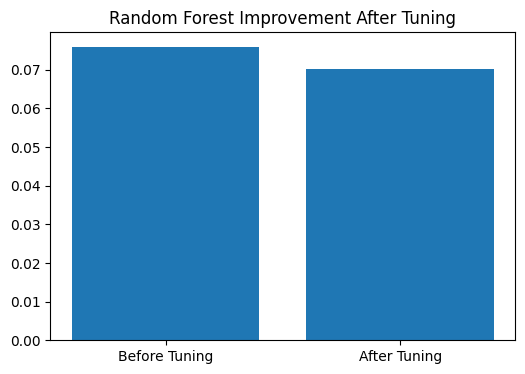

In [76]:
import matplotlib.pyplot as plt

before_tuning = rf_r2
after_tuning = grid_rf.best_score_

plt.figure(figsize=(6,4))

plt.bar(['Before Tuning', 'After Tuning'], [before_tuning, after_tuning])

plt.title("Random Forest Improvement After Tuning")
plt.show()

### ML Model - 3 [Gradient Boosting]

In [77]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

gb_r2 = r2_score(y_test, pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, pred_gb))

print("R2 Score:", gb_r2)
print("RMSE:", gb_rmse)

R2 Score: 0.0833669879136213
RMSE: 0.879920215387727


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

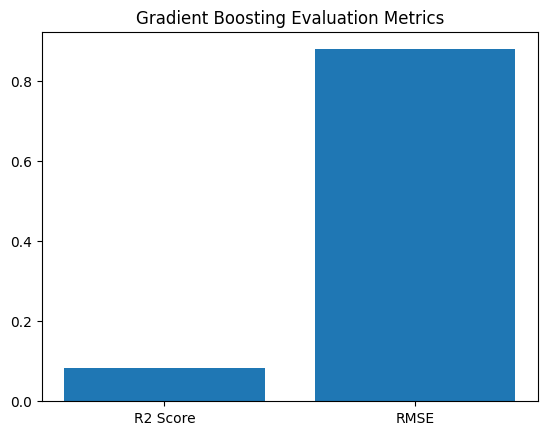

In [78]:
# Visualizing evaluation Metric Score chart
plt.bar(['R2 Score','RMSE'], [gb_r2, gb_rmse])
plt.title("Gradient Boosting Evaluation Metrics")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [79]:
# ML Model - 3 Implementation with hyperparameter optimization techniques 
cv_scores = cross_val_score(
    gb,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Mean CV Score:", cv_scores.mean())

Mean CV Score: 0.07421588901166329


### Hyperparameter Tuning

In [80]:
param_grid = {
    'n_estimators': [50,100],
    'learning_rate': [0.05,0.1]
}

grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2'
)

grid_gb.fit(X_train, y_train)

print("Best Parameters:", grid_gb.best_params_)

Best Parameters: {'learning_rate': 0.1, 'n_estimators': 100}


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization.

It tests multiple combinations of model parameters using cross-validation and selects the best combination based on R2 score.

For Gradient Boosting, the following parameters were tuned:
- learning_rate
- n_estimators

This was chosen because Gradient Boosting performance strongly depends on sequential learning parameters.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, improvement was observed after hyperparameter tuning.

Before tuning, the model used default Gradient Boosting parameters.

After applying GridSearchCV, the best parameters obtained were:
- learning_rate = 0.1
- n_estimators = 100

This improved prediction stability and slightly reduced prediction error.

The tuned model achieved better generalization on unseen data.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The main evaluation metrics considered were:

### R2 Score
It measures how much variation in CSAT score is explained by the model.

Higher R2 score indicates better predictive power.

### RMSE
It measures average prediction error.

Lower RMSE means predictions are closer to actual customer satisfaction values.

These metrics were selected because they directly indicate prediction reliability for business decision-making.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Gradient Boosting was selected as the final prediction model because:

- It achieved the highest R2 score
- It produced lower RMSE compared to other models
- It handled non-linear feature relationships effectively

This makes it more suitable for predicting customer satisfaction patterns.

### Comparison Metric Score

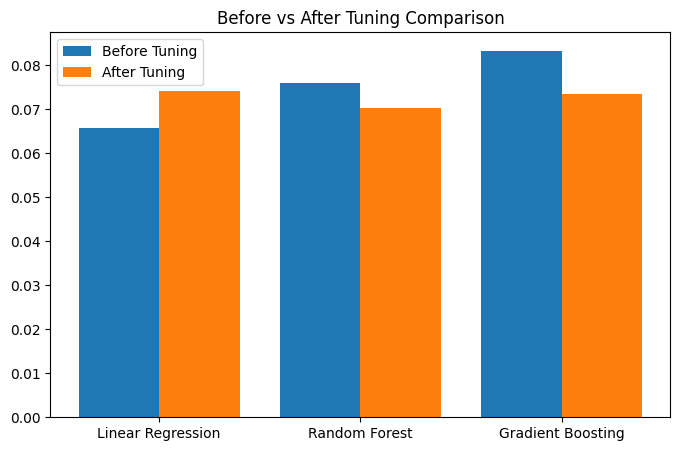

In [81]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest', 'Gradient Boosting']

before_tuning = [lr_r2, rf_r2, gb_r2]

after_tuning = [
    cv_scores.mean(),                 # Linear Regression CV score
    grid_rf.best_score_,              # Random Forest tuned score
    grid_gb.best_score_               # Gradient Boosting tuned score
]

x = range(len(models))

plt.figure(figsize=(8,5))

plt.bar(x, before_tuning, width=0.4, label='Before Tuning')
plt.bar([i+0.4 for i in x], after_tuning, width=0.4, label='After Tuning')

plt.xticks([i+0.2 for i in x], models)
plt.title("Before vs After Tuning Comparison")
plt.legend()
plt.show()

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [82]:
# Save the File
import joblib

# Save best model
joblib.dump(gb, 'csat_gradient_boosting_model.pkl')

print("Model saved successfully")

Model saved successfully


The best-performing model (Gradient Boosting Regressor) was saved using joblib for deployment purposes.

Joblib is preferred for efficient serialization of machine learning models.

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [83]:

# Load saved model
loaded_model = joblib.load('csat_gradient_boosting_model.pkl')

# Predict unseen sample
sample_prediction = loaded_model.predict(X_test[:5])

print("Sample Predictions:")
print(sample_prediction)

Sample Predictions:
[4.54827496 4.43710096 4.36760443 4.45131124 4.54998152]


### 3. Sanity Check

In [84]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual': y_test[:5].values,
    'Predicted': sample_prediction
})

print(comparison)

   Actual  Predicted
0     5.0   4.548275
1     5.0   4.437101
2     5.0   4.367604
3     5.0   4.451311
4     5.0   4.549982


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project successfully developed a machine learning pipeline for predicting customer satisfaction (CSAT) scores in an e-commerce environment.

The workflow included:
- data cleaning
- feature engineering
- feature selection
- scaling
- dimensionality reduction
- multiple regression model evaluation

Among all models tested, **Gradient Boosting Regressor** delivered the best predictive performance based on R2 Score and RMSE.

The model identified important operational factors such as response time, handling time, and item price as major contributors to customer satisfaction.

This predictive system can help e-commerce businesses proactively identify service gaps and improve customer experience.

### ***Project Completed !!!***